In [22]:

%pip install numpy matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation

'''Selecionar o Modo de Linguagem da Célula
matriz como função
M(v) = M @ v

as principais propriedades definem uma transformação linear

1. Aditividade: M(u + v) = M(u) + M(v)
2. Homogeneidade: M(αv) = αM(v)
3. M(0) = 0
4. M(-v) = -M(v)
5. M(u - v) = M(u) - M(v)
6. M(αu + βv) = αM(u) + βM(v)
7. M^n(v) = M(M(...M(v)...)) (n vezes)

com as duas priemiras ja conseguimos fazer a maioria das operações
com isso garantimos qulinahs retas se manhtem retas, planos se mantem planos, e a origem se mantem na origem

as propriedades parecem obvias mas são fundamentais para a definição de uma transformação linear e garentem que possamos usa-las como usamos, e se avançarmos nos conteudos vamos ver que elas não valem para todas as transformações, e isso é o que torna as transformações lineares 

'''
def aplicar(M, v):
    return M @ v

# testando a linearidade
M = np.array([[2, 1],
              [0, 3]], dtype=float)

a = np.array([1.0, 2.0])
b = np.array([3.0, 1.0])
c = 5.0

lhs = aplicar(M, a + b)
rhs = aplicar(M, a) + aplicar(M, b)
print("Aditividade:", np.allclose(lhs, rhs)) #np.allclose para comparar arrays com tolerância, se usar == pode dar falso por causa de precisão

lhs2 = aplicar(M, c * a)
rhs2 = c * aplicar(M, a)
print("Homogeneidade:", np.allclose(lhs2, rhs2))



# analises por meio das colunas 
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])

v = np.array([3.0, 2.0])
via_decomp = v[0] * (M @ e1) + v[1] * (M @ e2)
via_direto = M @ v

print(f"\nM @ {v} direto: {via_direto}")
print(f"M @ {v} por colunas: {via_decomp}")

## transformações canonicas
# se matrizes são transformações por definição, olhando pelo lado da geometria podemos aplicar transformações de forma (teria sido útil em introdução mecanica dos sólidos)
# definindo algumas trasnformações

def rotacao(theta):
    #depende de theta e vai no sentido antihorario
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                    [s, c]])

def escala(sx, sy):
    #a escala não é uniforme, cuidado com x e y pra nao distorcer  a imagem
    return np.array([[sx, 0],
                    [0, sy]])

def cisalhamento(k):
    return np.array([[1, 0],
                    [0, 1]])

def reflexao_x():
    return np.array([[1, 0],
                    [0, -1]])

def projecao_x():
    #projeta tudo no eixo x
    return np.array([[1, 0],
                    [0, 0]])

# determinante como fator de escala

#d etM > 0 --> mantém a orientação
# detM < 0 --> inverte a orientação
# detM = 0 --> perde a dimensão e colapsa

# na teoria de ML
# - det = 0 → matriz singular → sistema de equações sem solução única
# - det aparece em change-of-variables (acobiano)
# - det(XᵀX) = 0 --> regressão com features linearmente dependentes

import matplotlib.pyplot as plt
import matplotlib.patches as patches

'''
matriz como função
M(v) = M @ v

as principais propriedades definem uma transformação linear

1. Aditividade: M(u + v) = M(u) + M(v)
2. Homogeneidade: M(αv) = αM(v)
3. M(0) = 0
4. M(-v) = -M(v)
5. M(u - v) = M(u) - M(v)
6. M(αu + βv) = αM(u) + βM(v)
7. M^n(v) = M(M(...M(v)...)) (n vezes)

com as duas priemiras ja conseguimos fazer a maioria das operações
com isso garantimos qulinahs retas se manhtem retas, planos se mantem planos, e a origem se mantem na origem

as propriedades parecem obvias mas são fundamentais para a definição de uma transformação linear e garentem que possamos usa-las como usamos, e se avançarmos nos conteudos vamos ver que elas não valem para todas as transformações, e isso é o que torna as transformações lineares 

'''
def aplicar(M, v):
    return M @ v

# testando a linearidade
M = np.array([[2, 1],
              [0, 3]], dtype=float)

a = np.array([1.0, 2.0])
b = np.array([3.0, 1.0])
c = 5.0

lhs = aplicar(M, a + b)
rhs = aplicar(M, a) + aplicar(M, b)
print("Aditividade:", np.allclose(lhs, rhs)) #np.allclose para comparar arrays com tolerância, se usar == pode dar falso por causa de precisão

lhs2 = aplicar(M, c * a)
rhs2 = c * aplicar(M, a)
print("Homogeneidade:", np.allclose(lhs2, rhs2))



# analises por meio das colunas 
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])

v = np.array([3.0, 2.0])
via_decomp = v[0] * (M @ e1) + v[1] * (M @ e2)
via_direto = M @ v

print(f"\nM @ {v} direto: {via_direto}")
print(f"M @ {v} por colunas: {via_decomp}")

## transformações canonicas
# se matrizes são transformações por definição, olhando pelo lado da geometria podemos aplicar transformações de forma (teria sido útil em introdução mecanica dos sólidos)
# definindo algumas trasnformações

def rotacao(theta):
    #depende de theta e vai no sentido antihorario
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                    [s, c]])

def escala(sx, sy):
    #a escala não é uniforme, cuidado com x e y pra nao distorcer  a imagem
    return np.array([[sx, 0],
                    [0, sy]])

def cisalhamento(k):
    # cisalhamento horizontal
    return np.array([[1, k],
                    [0, 1]])

def reflexao_x():
    return np.array([[1, 0],
                    [0, -1]])

def projecao_x():
    #projeta tudo no eixo x
    return np.array([[1, 0],
                    [0, 0]])

# determinante como fator de escala

#d etM > 0 --> mantém a orientação
# detM < 0 --> inverte a orientação
# detM = 0 --> perde a dimensão e colapsa

# na teoria de ML
# - det = 0 → matriz singular → sistema de equações sem solução única
# - det aparece em change-of-variables (acobiano)
# - det(XᵀX) = 0 --> regressão com features linearmente dependentes

transformacoes = {
    'identidade':     np.eye(2),
    'rotação 45°':    rotacao(np.pi/4),
    'escala (2,1.5)': escala(2, 1.5),
    'cisalhamento':   cisalhamento(1.5),
    'reflexão x':     reflexao_x(),
    'projeção x':     projecao_x(),
}

print("\n--- Determinantes ---")
for nome, M_t in transformacoes.items():
    d = np.linalg.det(M_t)
    print(f"  {nome:20s}: det = {d:+.3f}")
    
    
# compondo transformações com multiplicação de matrizes
# a ordem importa, M1 @ M2 != M2 @ M1 

R90 = rotacao(np.pi/2)
E2 = escala(2, 1)

composta_1 = R90 @ E2
composta_2 = E2 @ R90

v_teste = np.array([1.0, 0.0])
print(f"\nescala→rotação:  {composta_1 @ v_teste}")
print(f"rotação→escala:  {composta_2 @ v_teste}")
print(f"São iguais? {np.allclose(composta_1 @ v_teste, composta_2 @ v_teste)}")

# aplicando em ml --> PCA, SVD, regularização ... são todas transformações lineares, e a maioria delas são compostas por rotações, escalas e cisalhamentos

np.random.seed(42)
n = 200
angulos_dados = np.pi / 5
cov = rotacao(angulos_dados) @ escala(2.5, 0.6)
dados = np.random.multivariate_normal([0, 0], cov @ cov.T, n).T

#fazendo o whitening manual para remover a correlação e escala para variancia unitaria
cov_dados = np.cov(dados)
vals, vecs = np.linalg.eig(cov_dados)
W_white = np.diag(1.0 / np.sqrt(vals)) @ vecs.T
dados_whitened = W_white @ dados

print(f"\nCovariância antes do whitening:")
print(np.round(np.cov(dados), 2))
print(f"\nCovariância depois do whitening:")
print(np.round(np.cov(dados_whitened), 2))  # deve ser próxima de identidade


Aditividade: True
Homogeneidade: True

M @ [3. 2.] direto: [8. 6.]
M @ [3. 2.] por colunas: [8. 6.]
Aditividade: True
Homogeneidade: True

M @ [3. 2.] direto: [8. 6.]
M @ [3. 2.] por colunas: [8. 6.]

--- Determinantes ---
  identidade          : det = +1.000
  rotação 45°         : det = +1.000
  escala (2,1.5)      : det = +3.000
  cisalhamento        : det = +1.000
  reflexão x          : det = -1.000
  projeção x          : det = +0.000

escala→rotação:  [1.2246468e-16 2.0000000e+00]
rotação→escala:  [1.2246468e-16 1.0000000e+00]
São iguais? False

Covariância antes do whitening:
[[3.83 2.58]
 [2.58 2.24]]

Covariância depois do whitening:
[[ 1. -0.]
 [-0.  1.]]


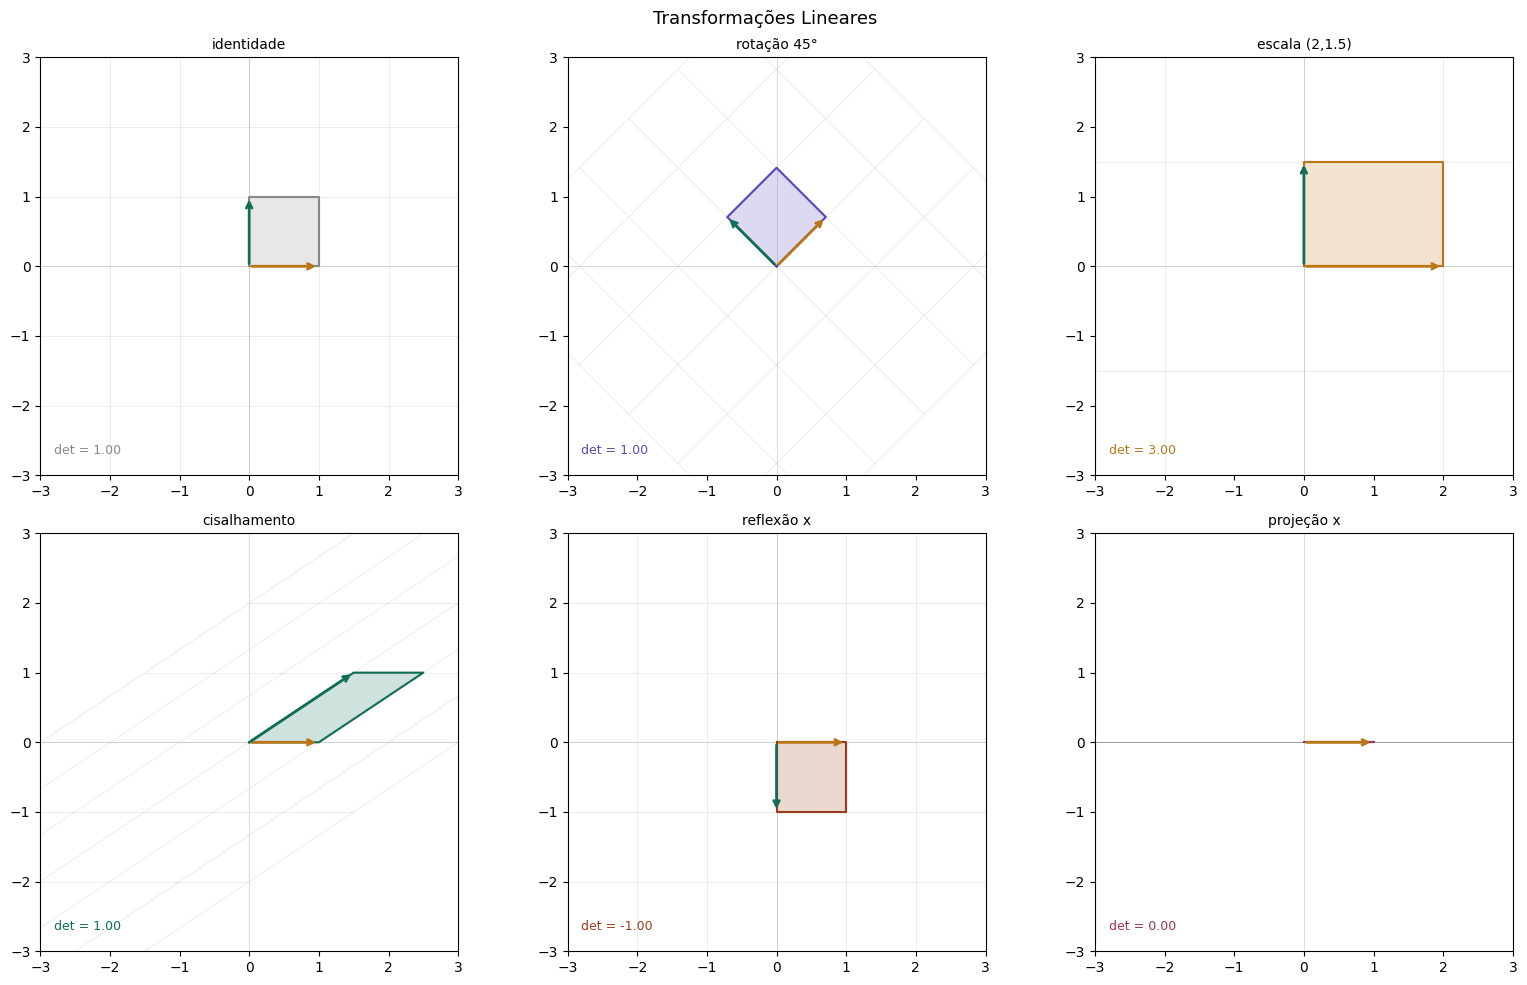

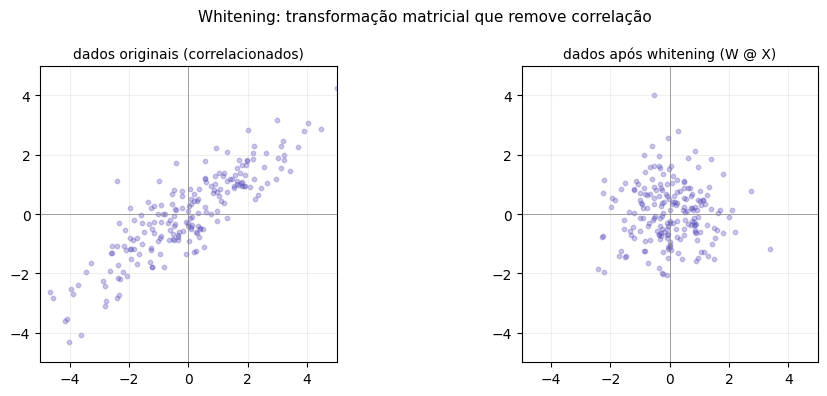

In [24]:

#visualizando
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Transformações Lineares", fontsize=13)

cores_transform = {
    'identidade':     '#888',
    'rotação 45°':    '#534AB7',
    'escala (2,1.5)': '#BA7517',
    'cisalhamento':   '#0F6E56',
    'reflexão x':     '#993C1D',
    'projeção x':     '#993556',
}

def desenhar_grade_e_quadrado(ax, M_t, titulo, cor):
    """Mostra como M_t transforma a grade e o quadrado unitário."""
    ax.set_title(titulo, fontsize=10)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5, alpha=0.4)
    ax.axvline(0, color='gray', lw=0.5, alpha=0.4)
    ax.grid(False)

    # grade original (cinza claro)
    for i in np.arange(-3, 4):
        pts_h = np.array([M_t @ np.array([x, float(i)]) for x in np.linspace(-3, 3, 50)])
        pts_v = np.array([M_t @ np.array([float(i), y]) for y in np.linspace(-3, 3, 50)])
        ax.plot(pts_h[:,0], pts_h[:,1], color='gray', lw=0.4, alpha=0.25)
        ax.plot(pts_v[:,0], pts_v[:,1], color='gray', lw=0.4, alpha=0.25)

    # quadrado unitário transformado
    corners = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T
    t_corners = M_t @ corners
    ax.fill(t_corners[0], t_corners[1], alpha=0.2, color=cor)
    ax.plot(t_corners[0], t_corners[1], color=cor, lw=1.5)

    # vetores base transformados
    e1_t = M_t @ np.array([1.0, 0.0])
    e2_t = M_t @ np.array([0.0, 1.0])
    ax.annotate("", xy=e1_t, xytext=(0,0),
        arrowprops=dict(arrowstyle='->', color='#BA7517', lw=2))
    ax.annotate("", xy=e2_t, xytext=(0,0),
        arrowprops=dict(arrowstyle='->', color='#0F6E56', lw=2))

    d = np.linalg.det(M_t)
    ax.text(-2.8, -2.7, f'det = {d:.2f}', fontsize=9, color=cor)
posicoes = [(fig, 2, 3, i+1) for i in range(6)]
for i, (nome, M_t) in enumerate(transformacoes.items()):
    ax = fig.add_subplot(2, 3, i+1)
    cor = cores_transform[nome]
    desenhar_grade_e_quadrado(ax, M_t, nome, cor)

plt.tight_layout()
#plt.savefig('../assets/02_matrices_transformations.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot separado: whitening
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
fig2.suptitle("Whitening: transformação matricial que remove correlação", fontsize=11)

for ax, d, titulo in zip(axes2,
                          [dados, dados_whitened],
                          ['dados originais (correlacionados)',
                           'dados após whitening (W @ X)']):
    ax.scatter(d[0], d[1], alpha=0.3, s=10, color='#534AB7')
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(titulo, fontsize=10)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
#plt.savefig('../assets/02_whitening.png', dpi=150, bbox_inches='tight')
plt.show()
